In [1]:
from pathlib import Path

path = Path("sar.sdf")
print(path.exists())
print(path.stat().st_size)
print(path.read_text(errors="ignore")[:1000])

True
2368
Molecule Name
 OpenBabel04232619403D

 25 24  0  0  0  0  0  0  0  0999 V2000
   -3.2473   -0.4762   -0.8057 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.9678   -0.6260    0.0030 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.6173   -1.7286    0.4271 O   0  0  0  0  0  0  0  0  0  0  0  0
   -1.2314    0.5090    0.2269 N   0  0  0  0  0  0  0  0  0  0  0  0
   -0.0539    0.4257    1.0949 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.2458    0.6696    0.3095 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5676    1.8341    0.0593 O   0  0  0  0  0  0  0  0  0  0  0  0
    1.9920   -0.4011   -0.0951 N   0  0  0  0  0  0  0  0  0  0  0  0
    1.6626   -1.8074    0.1136 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.2505   -0.1501   -0.7868 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.7532   -1.4409   -0.7975 H   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0307   -0.2001   -1.8433 H   0  0  0  0  0  0  0  0  0  0  0  0
   -3.9118    0.2877   -0.3909 H   0  0  0  0  0  0  0  0  0  0  0  0
  

In [2]:
from rdkit import Chem

suppl = Chem.SDMolSupplier("sar.sdf", removeHs=False, sanitize=False)

mols = [m for m in suppl if m is not None]
print("number of readable molecules:", len(mols))

for i, m in enumerate(suppl):
    if m is None:
        print("failed at molecule", i)

number of readable molecules: 1


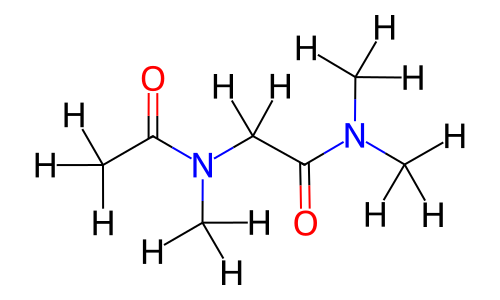

In [3]:
from openff.toolkit import Molecule

mol = Molecule.from_file("sar.sdf")

# visualize
mol.visualize()

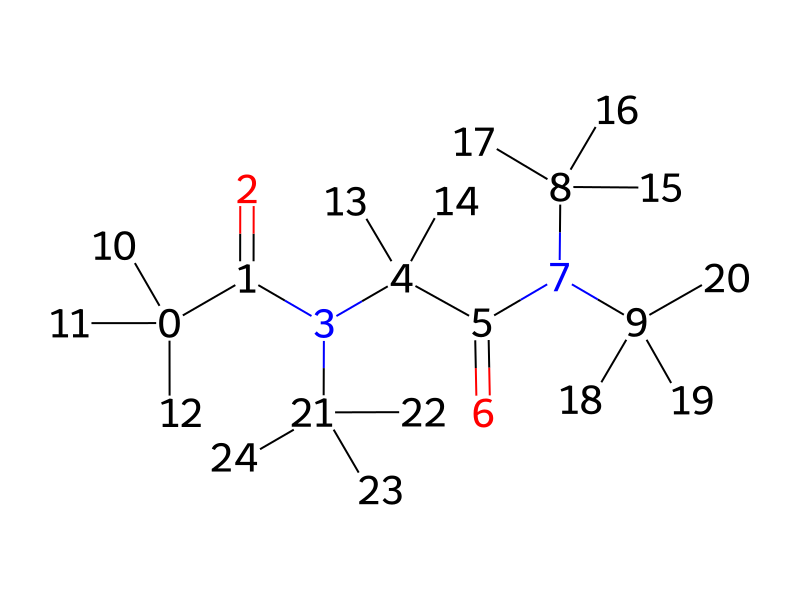

In [4]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display

rdmol = Chem.MolFromMolFile("sar.sdf", removeHs=False)

for atom in rdmol.GetAtoms():
    atom.SetProp("atomLabel", str(atom.GetIdx()))

rdDepictor.Compute2DCoords(rdmol)

drawer = rdMolDraw2D.MolDraw2DCairo(800, 600)
drawer.DrawMolecule(rdmol)
drawer.FinishDrawing()

with open("s00.png", "wb") as f:
    f.write(drawer.GetDrawingText())

display(Image(filename="s00.png"))

In [5]:
import sys
print(sys.executable)

try:
    import openmm
    import openmm.app as app
    import openmm.unit as unit
    print("OpenMM installed")
    print("OpenMM version:", openmm.version.version)
except Exception as e:
    print("OpenMM import failed")
    print(e)

try:
    from openff.toolkit import Molecule, ForceField
    print("OpenFF Toolkit installed")
except Exception as e:
    print("OpenFF import failed")
    print(e)

/home/tuu61186/miniconda3/envs/openff/bin/python
OpenMM installed
OpenMM version: 8.5.1.dev-f7fa0c2
OpenFF Toolkit installed


In [1]:
from openff.toolkit import Molecule, ForceField
import openmm
import openmm.app as app
import openmm.unit as unit

mol = Molecule.from_file("sar.sdf")

if not mol.conformers:
    mol.generate_conformers(n_conformers=1)

ff = ForceField("openff-2.2.0.offxml")
interchange = ff.create_interchange(mol.to_topology())

system = interchange.to_openmm()
topology = interchange.topology.to_openmm()
positions = interchange.positions.to_openmm()

/home/tuu61186/miniconda3/envs/openff/lib/python3.10/site-packages/openff/amber_ff_ports/amber_ff_ports.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [9]:
sbatch run_openmm_md.sh

SyntaxError: invalid syntax (2661807581.py, line 1)

In [ ]:
import mdtraj as md
import numpy as np

traj = md.load("traj.dcd", top="topology.pdb")

phi_atoms = [1, 3, 4, 5]  # phi atom index
psi_atoms = [3, 4, 5, 7]  # psi atom index

angles = md.compute_dihedrals(traj, [phi_atoms, psi_atoms])

phi = np.degrees(angles[:, 0])
psi = np.degrees(angles[:, 1])

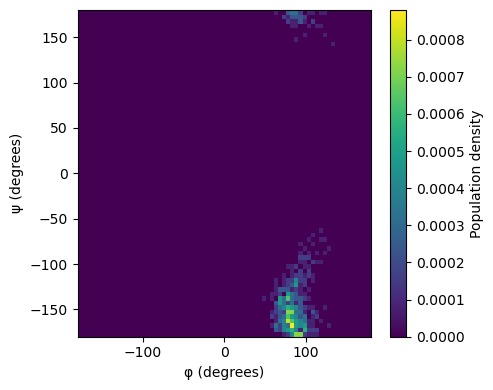

In [16]:
import matplotlib.pyplot as plt

H, xedges, yedges = np.histogram2d(
    phi,
    psi,
    bins=72,
    range=[[-180, 180], [-180, 180]],
    density=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(
    H.T,
    origin="lower",
    extent=[-180, 180, -180, 180],
    aspect="auto",
)

plt.xlabel("φ (degrees)")
plt.ylabel("ψ (degrees)")
plt.colorbar(label="Population density")
plt.tight_layout()
plt.savefig("phi_psi_population_map.png", dpi=300)
plt.show()

20 conformers

In [2]:
from openff.toolkit import Molecule, ForceField
import openmm
import openmm.app as app
import openmm.unit as unit

mol = Molecule.from_file("sar.sdf")

if not mol.conformers:
    mol.generate_conformers(n_conformers=20)

ff = ForceField("openff-2.2.0.offxml")
interchange = ff.create_interchange(mol.to_topology())

system = interchange.to_openmm()
topology = interchange.topology.to_openmm()
positions = interchange.positions.to_openmm()

In [ ]:
sbatch run_20.sh

In [5]:
import mdtraj as md
import numpy as np

traj_files = [f"traj_{i}.dcd" for i in range(6)]
traj = md.load(traj_files, top="topology.pdb")

phi_atoms = [1, 3, 4, 5]  # phi atom index
psi_atoms = [3, 4, 5, 7]  # psi atom index

angles = md.compute_dihedrals(traj, [phi_atoms, psi_atoms])

phi = np.degrees(angles[:, 0])
psi = np.degrees(angles[:, 1])

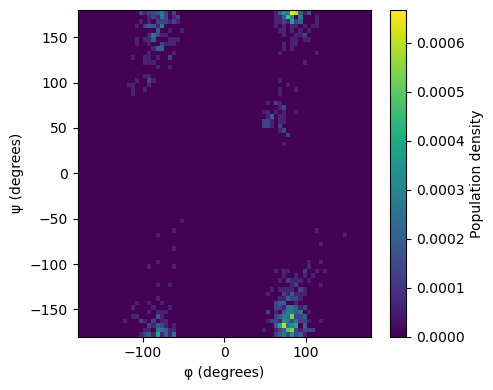

In [6]:
import matplotlib.pyplot as plt

H, xedges, yedges = np.histogram2d(
    phi,
    psi,
    bins=72,
    range=[[-180, 180], [-180, 180]],
    density=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(
    H.T,
    origin="lower",
    extent=[-180, 180, -180, 180],
    aspect="auto",
)

plt.xlabel("φ (degrees)")
plt.ylabel("ψ (degrees)")
plt.colorbar(label="Population density")
plt.tight_layout()
plt.savefig("phi_psi_population_map.png", dpi=300)
plt.show()